In [9]:
from math import pi
from typing import Union, overload
import numpy as np
from daceypy import DA, array
from daceypy.op import cos, sin, sqrt, asin, tan, atan  # can be used on DA and on floats
from inspect import getsourcefile
from pathlib import Path
import matplotlib.pyplot as plt
from time import perf_counter


In [10]:
#Ex4.1.1: Proving correct zeroth order solution required for strong convergent algorthms
#Ex:4.1.2 Verify strong convergence alogirhtm by looking at the residual at each convergence step
#Ex4.1.3 Create a Naive Newton iterator and DA newton iterator and compare
#Ex4.1.4:
def Nf(x: Union[float, DA], p: Union[float,DA]) -> Union[float, DA]:
    return x - (x*x - p) / (2 * x)              #x - (f(x;p) / f'(x;p) for square root formula

order = 10
DA.init(order,1)

x0 = 1
p0 = 1                                          #For p0=1 (chosen), x0 = 1 when solving f(x;p) = 0
x = x0                                          #place zeroth order solution into the equation
p = p0 + DA(1)                                  #parameterised is a DA number
i = 1
counter = 1
T0 = perf_counter()
while i <= order:                               #DA iteration
    x = Nf(x,p)
    i *= 2                                       #Property of the Newton raphson iterator
    print(f"Iteration {counter} \n")
    print(f"x:\n{x}\n")
    counter += 1
T1 = perf_counter()
print(f"Run time {T1 - T0}\n")


Iteration 1 

x:
     I  COEFFICIENT              ORDER EXPONENTS
     1    1.0000000000000000e+00   0   0
     2    5.0000000000000000e-01   1   1
------------------------------------------------

Iteration 2 

x:
     I  COEFFICIENT              ORDER EXPONENTS
     1    1.0000000000000000e+00   0   0
     2    5.0000000000000000e-01   1   1
     3   -1.2500000000000000e-01   2   2
     4    6.2500000000000000e-02   3   3
     5   -3.1250000000000000e-02   4   4
     6    1.5625000000000000e-02   5   5
     7   -7.8125000000000000e-03   6   6
     8    3.9062500000000000e-03   7   7
     9   -1.9531250000000000e-03   8   8
    10    9.7656250000000000e-04   9   9
    11   -4.8828125000000000e-04  10  10
------------------------------------------------

Iteration 3 

x:
     I  COEFFICIENT              ORDER EXPONENTS
     1    1.0000000000000000e+00   0   0
     2    5.0000000000000000e-01   1   1
     3   -1.2500000000000000e-01   2   2
     4    6.2500000000000000e-02   3   3
     

Choose p0 as the expansion point; i.e. the nomial implicit parameter. Then solve f(x;p) = 0 for x when enforcing this condition. This generates the zeroth order solution which enables the DA arthimetic newton solver. This means we can use the i *= 2 and solve the iteration within a finite number of steps. Drifting from x0 = 1 results in an expansion polynomial around p=1 which is wrong. This it is a taylor series polynomial at the end of the day. The solution is only correct within a radius of convergence

In [11]:
#Ex4.1.3 Naive Netwon Solver using tol and error as stopping conditionr
# Show that need x0 to be nominal solution variable

tol = 1e-9
x0  = 4.0
p0 = np.linspace(0.1,1,10)

for p0_n in p0:
    p = p0_n + DA(1)
    x = DA(x0)
    xp = DA()
    flag = True
    counter = 0

    T0 = perf_counter()
    while flag:
        xp = Nf(x, p)
        counter += 1
        flag = abs(xp - x) > tol
        x.assign(xp)

    T1 = perf_counter()

    print(f"p0:\n{p0_n}\n")
    print(f"Iterations {counter}\n")
    print(f"Run time {T1 - T0}\n")
    print(f"Naive Newton Solution x:\n{x}\n")

    #Re-initalise
    x2 = DA(x0)
    counter_2 = 0
    i = 1
    
    ## Strongly Convergent Newton DA#
    T0_2 = perf_counter()
    while i <= order:                               #DA iteration
        x2 = Nf(x2,p)
        i *= 2                                       #Property of the Newton raphson iterator
        counter_2 += 1

    T1_2 = perf_counter()

    print(f"p0:\n{p0_n}\n")
    print(f"Iteration {counter_2} \n")
    print(f"Run time {T1_2 - T0_2}\n")
    print(f"Strongly Iterative Solution:\n{x2}\n")

    #Print the difference between the coefficents. Take the Naive Newton as the refernce
    print(f"p0:\n{p0_n}\n")
    print(f"Difference in solution:\n {x - x2}\n")
    print(f"Difference in iterations:\n {counter - counter_2}\n")           #if positive it means that Naive has taken x more iterations
    print(f"Difference in Run time:\n {(T1 - T0)-(T1_2 - T0_2)}\n")
    print("-------------------------")




p0:
0.1

Iterations 11

Run time 0.004074600001331419

Naive Newton Solution x:
     I  COEFFICIENT              ORDER EXPONENTS
     1    3.1622776601683794e-01   0   0
     2    1.5811388300841898e+00   1   1
     3   -3.9528470752104745e+00   2   2
     4    1.9764235376052373e+01   3   3
     5   -1.2352647110032733e+02   4   4
     6    8.6468529770229145e+02   5   5
     7   -6.4851397327671866e+03   6   6
     8    5.0954669328885037e+04   7   7
     9   -4.1400668829719094e+05   8   8
    10    3.4500557358099245e+06   9   9
    11   -2.9325473754384357e+07  10  10
------------------------------------------------

p0:
0.1

Iteration 4 

Run time 0.0002473999629728496

Strongly Iterative Solution:
     I  COEFFICIENT              ORDER EXPONENTS
     1    3.7066602745008503e-01   0   0
     2    1.1007604988981796e+00   1   1
     3   -9.2428688468922038e-01   2   2
     4    1.1661885324630807e+00   3   3
     5   -1.5633393933973208e+00   4   4
     6    2.1235540878875518e+00

Where the Final iteration is the correct zeroth order guess for the nomial implicit parameter.

As the nomial guess gets closer to correct zeroth order estimate for a given p (x0 = 1 while p0 = 1), there is no accuracy difference between the Naive Netwon DA and the strongly convergent algorthm. The strong convergent algorithm is reliably faster than the Naive DA algorithm, this is because less iterations are required to reach convergence.

The Naive DA algorithm is more robust, it can generate a taylor polynomial for any combination of x0 and p. However, this is only correct for that specific condition. The strongly convergent algorithm converges on a value outside the radius of convergence, as the zeroth order is not 1 (x0 != 1). However, when the strongly iterative algorithm is correct, it better describes x(dp) for an array of dp around the nomial point p0.

In [ ]:
#Advanced excerises
#Ex 4.1.1: Full Newton solver. Do float Nf to get the zeroth order solution, then do DA Nf to get the taylor polynomial abount the zeroth order solution
def newton_DA(p0: float):
    tol = 1e-14
    x0 = p0                   #arbitary initial guess
    i = 0

    #Generate zeroth order guess
    flag = True
    counter = 0
    xp = x0
    while flag:
        x = Nf(xp, p0)             #This returns the newton iteration of the function f(x;p). This is done analytically but can do                                   through automatic differentition for larger datasets
        counter += 1
        flag = abs(xp - x) > tol and i < 1000
        xp = x
    
    x0 = x
    # DA computation
    p = p0 + DA(1)
    x = x0                              #first guess is zeroth order solution
    i = 1
    while i <= order:
        x = Nf(x, p)
        i*=2

    print(f"Full DA Newton solution:\n{x}\n")
    return x


x = newton_DA(4)
print(x)

Full DA Newton solution:
     I  COEFFICIENT              ORDER EXPONENTS
     1    2.0000000000000000e+00   0   0  0
     2    2.5000000000000000e-01   1   1  0
     3   -1.5625000000000000e-02   2   2  0
     4    1.9531250000000000e-03   3   3  0
     5   -3.0517578125000000e-04   4   4  0
     6    5.3405761718750000e-05   5   5  0
     7   -1.0013580322265625e-05   6   6  0
------------------------------------------------

     I  COEFFICIENT              ORDER EXPONENTS
     1    2.0000000000000000e+00   0   0  0
     2    2.5000000000000000e-01   1   1  0
     3   -1.5625000000000000e-02   2   2  0
     4    1.9531250000000000e-03   3   3  0
     5   -3.0517578125000000e-04   4   4  0
     6    5.3405761718750000e-05   5   5  0
     7   -1.0013580322265625e-05   6   6  0
------------------------------------------------


Expansion of the Eccentric anomoly:
     I  COEFFICIENT              ORDER EXPONENTS
     1    2.0000000000000000e+00   1   1
     2   -1.3333333333333333e+00   3   3
     3    2.9333333333333331e+00   5   5
     4   -8.5587301587301567e+00   7   7
     5    2.8595414462081120e+01   9   9
------------------------------------------------

Residual Error:
     I  COEFFICIENT              ORDER EXPONENTS
     1   -3.5527136788005009e-15   9   9
------------------------------------------------


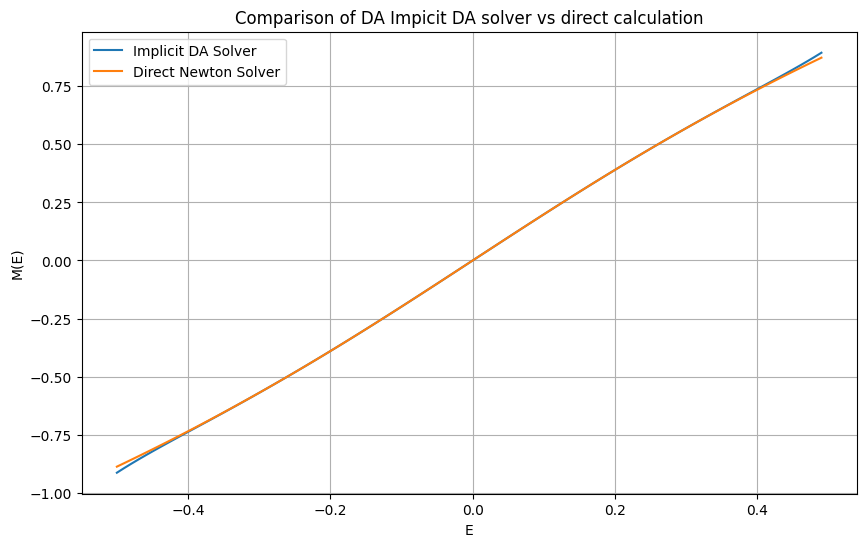

In [13]:
#Ex4.2.2: Expand eccentric anomoly as a function of mean anomaly M for fixed eccentricity via Keplers equation M = E - esinE
def Nkep(E: Union[float, DA], M: Union[float, DA], ecc: Union[float,DA]) -> Union[float, DA]: #construct the newton iteration equation for Keplers equation
    return E - (E - ecc * sin(E)- M)/(1 - ecc*cos(E))

def newton_Kep_DA(M0: float, ecc: float) -> Union[float, DA]:
    tol = 1e-14
    E0 = M0                   #arbitary initial guess

    #Generate zeroth order guess
    flag = True
    counter = 0
    while flag:
        Ep = E0
        E0 = Nkep(E0, M0, ecc)             #This returns the newton iteration of the function f(x;p). This is done analytically but can do                                   through automatic differentition for larger datasets
        counter += 1
        flag = abs(Ep - E0) > tol and counter < 1000

    # DA computation
    M = M0 + DA(1)
    E = E0                              #first guess is zeroth order solution
    i = 1
    while i <= order:
        E = Nkep(E, M, ecc)
        i*=2

    print(f"Expansion of the Eccentric anomoly:\n{E}\n")
    print(f"Residual Error:\n{E-ecc*sin(E)-M}")             #This is the residual error as E-ecc*sin(E)-M = 0 for Newton. f(E;M) - 0 = error

    return E

def kepler(M0: float, ecc: float) -> float:                      #Example of automatic differention, not polynomial evaluation. So                                                                         we do not create a taylor map and evaluate it
    tol =1e-12
    E0 = M0                   #arbitary initial guess
    i = 0

    #Generate zeroth order guess
    flag = True
    counter = 0
    while flag:
        Ep = E0
        E0 = Nkep(E0, M0, ecc)             #This returns the newton iteration of the function f(x;p). This is done analytically but can do                                   through automatic differentition for larger datasets
        counter += 1
        flag = abs(Ep - E0) > tol and i < 1000
    return E0

############################### Start Main Function

ecc = 0.5
M0 = 0
E  = newton_Kep_DA(M0, ecc)                             #E as a function of M, in form of DA therefore E(dM)

################################ sample the E polynomial over M0 -/+ 3 radians
M_points = []
E_DApoints = []
E_Directpoints = []
for i in range(-50,50):
    M_i = M0 + i / 100.0
    E_i = E.evalScalar(i / 100.0)                   # E(dM) evaluation for the Implicit equation solver.
    E_direct_i = kepler(M_i,ecc)                                   # Direct Newton Solver from Keplers equations
    M_points.append(M_i)
    E_DApoints.append(E_i)
    E_Directpoints.append(E_direct_i)

##############################  Plots

plt.figure(figsize=(10, 6))
plt.plot(M_points, E_DApoints, label='Implicit DA Solver')
plt.plot(M_points, E_Directpoints, label='Direct Newton Solver')
plt.xlabel('E')
plt.ylabel('M(E)')
plt.title('Comparison of DA Impicit DA solver vs direct calculation')
plt.legend()
plt.grid(True)
plt.show()


Based on PLots, the convergence radius is about +/- 0.4 Eccentric anomoly for an DA expansion to the 10th order

In [14]:
#Ex 4.2.3: True anomaly as a function of mean anomaly M and eccentricity e.
def true_anomaly(E: Union[float, DA], M: Union[float, DA], ecc: Union[float,DA]) -> Union[float, DA]:
    top = sqrt(1 - ecc**2) * sin(E)
    bottom = 1 - ecc * cos(E)
    f = asin(top / bottom)
    return f



Expansion of the Eccentric anomaly:
     I  COEFFICIENT              ORDER EXPONENTS
     1    1.4285714285714286e+00   1   1  0
     2    2.0408163265306123e+00   2   1  1
     3    2.9154518950437320e+00   3   1  2
     4   -2.0824656393169508e-01   3   3  0
     5    4.1649312786339028e+00   4   1  3
     6   -1.8841355784296221e+00   4   3  1
     7    5.9499018266198611e+00   5   1  4
     8   -8.2165310939036171e+00   5   3  2
     9    1.1231957529843609e-01   5   5  0
    10    8.4998597523140891e+00   6   1  5
    11   -2.6309089709543599e+01   6   3  3
    12    1.7708041150654343e+00   6   5  1
------------------------------------------------

Expansion of the True anomaly:
        ALL COEFFICIENTS ZERO
------------------------------------------------

Residual Error:
     I  COEFFICIENT              ORDER EXPONENTS
     1    2.2204460492503131e-16   4   3  1
     2   -1.3877787807814457e-17   5   5  0
     3    1.7763568394002505e-15   6   1  5
-----------------------------

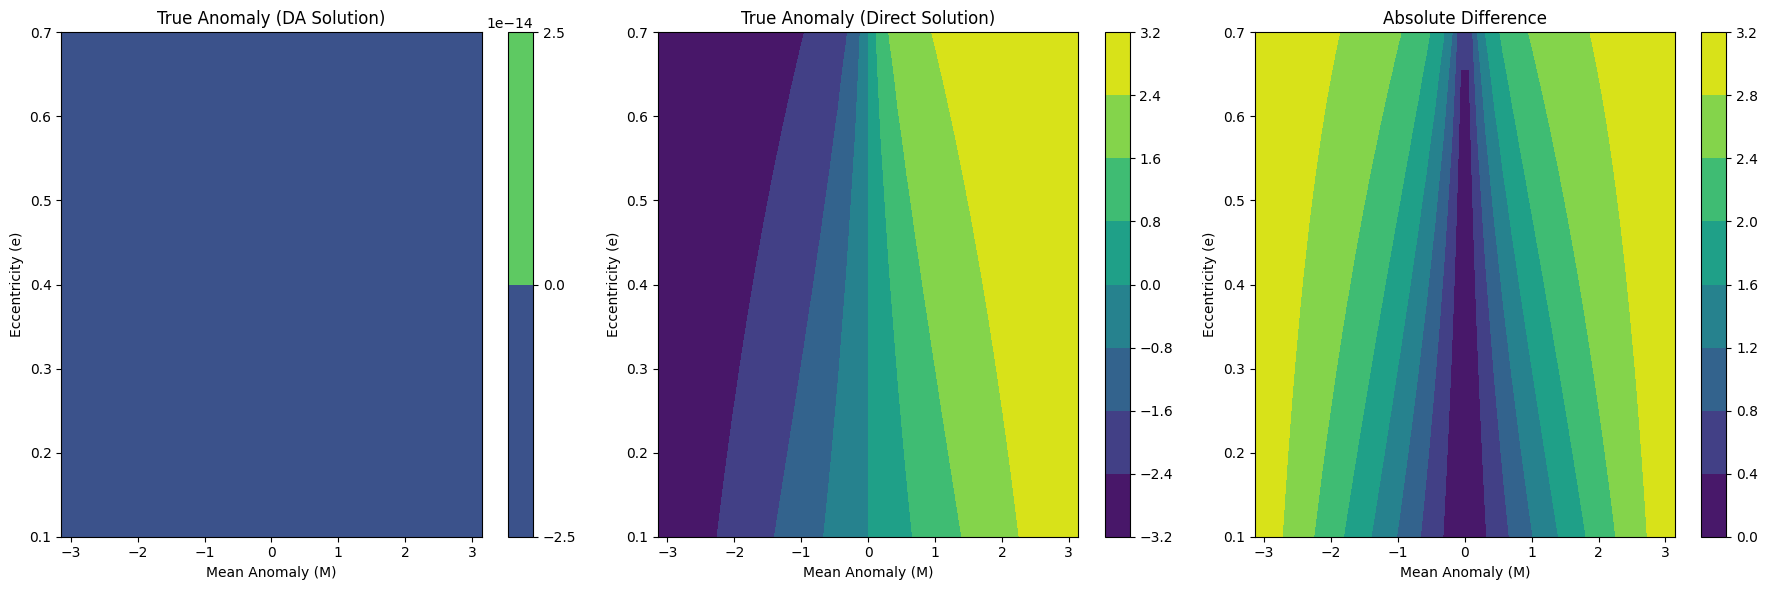

In [15]:
from math import pi
from typing import Union
import numpy as np
from daceypy import DA
from daceypy.op import cos, sin, asin, sqrt, atan2,tan
import matplotlib.pyplot as plt

def Nkep(E: Union[float, DA], M: Union[float, DA], ecc: Union[float,DA]) -> Union[float, DA]:
    return E - (E - ecc * sin(E) - M)/(1 - ecc*cos(E))

def true_anomaly_from_eccentric(E: Union[float, DA], ecc: Union[float, DA]) -> Union[float, DA]:
    # Calculate true anomaly f from eccentric anomaly E
    # Using the formula: tan(f/2) = sqrt((1+e)/(1-e)) * tan(E/2)
    term = sqrt((1 + ecc)/(1 - ecc)) * tan(E/2)
    # Convert the integer 1 to DA type when working with DA objects
    if isinstance(term, DA):
        return 2 * atan2(term, DA(1))
    return 2 * atan2(term, 1)


def newton_Kep_DA_2param(M0: float, ecc0: float) -> Union[float, DA]:
    tol = 1e-14
    E0 = M0

    # Generate zeroth order guess for initial eccentricity
    flag = True
    counter = 0
    while flag:
        Ep = E0
        E0 = Nkep(E0, M0, ecc0)
        counter += 1
        flag = abs(Ep - E0) > tol and counter < 1000

    # DA computation with two variables
    # First variable (index 0) for M, Second variable (index 1) for ecc
    DA.init(order, 2)  # Initialize DA with 2 variables

    M = M0 + DA(1)      # First variable represents dM
    ecc = ecc0 + DA(2)  # Second variable represents de

    E = E0                 # First guess is zeroth order solution
    i = 1
    while i <= order:
        E = Nkep(E, M, ecc)
        i *= 2

    # Calculate true anomaly
    f = true_anomaly_from_eccentric(E, ecc)

    print(f"Expansion of the Eccentric anomaly:\n{E}\n")
    print(f"Expansion of the True anomaly:\n{f}\n")
    print(f"Residual Error:\n{E-ecc*sin(E)-M}")

    return E, f

def kepler_true_anomaly(M0: float, ecc: float) -> tuple[float, float]:
    """Direct numerical solution for both eccentric and true anomaly"""
    tol = 1e-12
    E0 = M0

    flag = True
    counter = 0
    while flag:
        Ep = E0
        E0 = Nkep(E0, M0, ecc)
        counter += 1
        flag = abs(Ep - E0) > tol and counter < 1000

    # Calculate true anomaly from converged eccentric anomaly
    f0 = true_anomaly_from_eccentric(E0, ecc)
    return E0, f0

############################### Start Main Function
order = 6  # Order of DA expansion
M0 = 0.0   # Nominal mean anomaly
ecc0 = 0.3 # Nominal eccentricity

# Get DA expansions for both E and f
E_DA, f_DA = newton_Kep_DA_2param(M0, ecc0)

################################ Sample over a grid of M and e values
M_vals = np.linspace(-pi, pi, 50)
e_vals = np.linspace(0.1, 0.7, 50)
M_grid, e_grid = np.meshgrid(M_vals, e_vals)

# Calculate true anomaly using both methods
f_DA_points = np.zeros_like(M_grid)
f_direct_points = np.zeros_like(M_grid)

for i in range(len(M_vals)):
    for j in range(len(e_vals)):
        # DA evaluation
        dM = M_vals[i] - M0
        de = e_vals[j] - ecc0
        f_DA_points[j,i] = f_DA.eval([dM, de])

        # Direct calculation
        _, f_direct = kepler_true_anomaly(M_vals[i], e_vals[j])
        f_direct_points[j,i] = f_direct

##############################  Plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot DA solution
im1 = ax1.contourf(M_grid, e_grid, f_DA_points)
ax1.set_xlabel('Mean Anomaly (M)')
ax1.set_ylabel('Eccentricity (e)')
ax1.set_title('True Anomaly (DA Solution)')
plt.colorbar(im1, ax=ax1)

# Plot direct solution
im2 = ax2.contourf(M_grid, e_grid, f_direct_points)
ax2.set_xlabel('Mean Anomaly (M)')
ax2.set_ylabel('Eccentricity (e)')
ax2.set_title('True Anomaly (Direct Solution)')
plt.colorbar(im2, ax=ax2)

# Plot difference
diff = np.abs(f_DA_points - f_direct_points)
im3 = ax3.contourf(M_grid, e_grid, diff)
ax3.set_xlabel('Mean Anomaly (M)')
ax3.set_ylabel('Eccentricity (e)')
ax3.set_title('Absolute Difference')
plt.colorbar(im3, ax=ax3)

plt.tight_layout()
plt.show()

This Needs to be fixed = Its AI code and its incorrect